# This script provides some basic exploratory data analysis for the RealWaste dataset, as well as for the cleaned dataset that classifies the categories of waste into recyclable and non-recyclable.

In [ ]:
#class sizes
#example images
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
data_dir = "/content/drive/MyDrive/#3 - Data Science Project/RealWaste"

In [ ]:
import os

print(os.listdir(data_dir))

['Textile Trash', 'Vegetation', 'Plastic', 'Paper', 'Metal', 'Miscellaneous Trash', 'Cardboard', 'Glass', 'Food Organics']


In [ ]:

class_counts = {}

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):  # make sure it's a folder
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        class_counts[class_name] = count

print(class_counts)

{'Textile Trash': 318, 'Vegetation': 436, 'Plastic': 921, 'Paper': 500, 'Metal': 790, 'Miscellaneous Trash': 495, 'Cardboard': 461, 'Glass': 420, 'Food Organics': 411}


                 Class  Count
2              Plastic    921
4                Metal    790
3                Paper    500
5  Miscellaneous Trash    495
6            Cardboard    461
1           Vegetation    436
7                Glass    420
8        Food Organics    411
0        Textile Trash    318


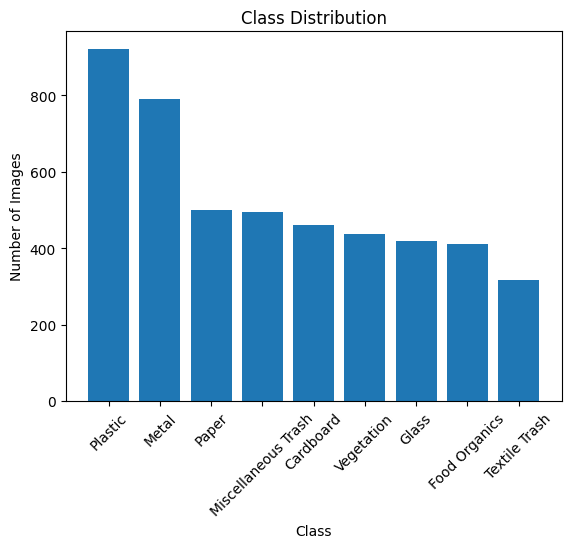

In [ ]:
import pandas as pd

df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"])
df = df.sort_values(by="Count", ascending=False)

print(df)

import matplotlib.pyplot as plt

plt.figure()
plt.bar(df["Class"], df["Count"])
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
total_images = sum(class_counts.values())
print("Total images:", total_images)

Total images: 4752


In [ ]:
print("Largest class:", df.iloc[0])
print("Smallest class:", df.iloc[-1])

Largest class: Class    Plastic
Count        921
Name: 2, dtype: object
Smallest class: Class    Textile Trash
Count              318
Name: 0, dtype: object


In [ ]:
import os
import shutil

base_dir = "/content/drive/MyDrive/#3 - Data Science Project/RealWaste"
new_base_dir = "/content/drive/MyDrive/#3 - Data Science Project/CleanedDataset"

recyclable_dir = os.path.join(new_base_dir, "Recyclable")
non_recyclable_dir = os.path.join(new_base_dir, "Non_Recyclable")

os.makedirs(recyclable_dir, exist_ok=True)
os.makedirs(non_recyclable_dir, exist_ok=True)

In [ ]:
recyclable_classes = ["Cardboard", "Paper", "Glass", "Metal"]
non_recyclable_classes = ["Miscellaneous Trash", "Textile Trash", "Food Organics", "Vegetation"]

In [ ]:
def copy_images(class_list, target_dir):
    for class_name in class_list:
        class_path = os.path.join(base_dir, class_name)

        if not os.path.exists(class_path):
            print(f"Skipping missing folder: {class_name}")
            continue

        for img_name in os.listdir(class_path):
            src = os.path.join(class_path, img_name)

            # Add class name to avoid filename collisions
            dst = os.path.join(target_dir, f"{class_name}_{img_name}")

            try:
                shutil.copy(src, dst)
            except Exception as e:
                print(f"Error copying {src}: {e}")

In [ ]:
copy_images(recyclable_classes, recyclable_dir)
copy_images(non_recyclable_classes, non_recyclable_dir)

In [ ]:
print("Recyclable count:", len(os.listdir(recyclable_dir)))
print("Non-Recyclable count:", len(os.listdir(non_recyclable_dir)))